# S11 – Компьютерное зрение (PyTorch): Сегментация «из коробки» и IoU

В этом ноутбуке:
- запускаем **готовую модель семантической сегментации** из `torchvision` (DeepLabV3);
- выделяем класс **person**;
- считаем **IoU** (intersection-over-union) по бинарной маске «человек / фон».

Для GT используем тот же PennFudanPed:
- в датасете есть **instance masks** (каждый человек – свой id),
- мы превращаем их в одну бинарную маску «хотя бы один человек».

Важно: это демонстрация корректной валидации. Мы не дообучаем модель, только проверяем, что метрика считается честно.


In [1]:
# 1) Импорты и общие настройки
import os
import math
import random
from dataclasses import dataclass
from typing import List, Dict, Tuple

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch

print("torch:", torch.__version__)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)

def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(42)

torch: 2.10.0+cu128
device: cuda


In [2]:
# 2) Конфигурация
@dataclass
class RunConfig:
    data_dir: str = "./data"
    fast_mode: bool = False
    n_show: int = 3
    person_only: bool = True  # мы считаем IoU только по классу "person"

cfg = RunConfig()
cfg

RunConfig(data_dir='./data', fast_mode=False, n_show=3, person_only=True)

In [3]:
# 3) Данные: PennFudanPed (та же загрузка, что и в детекции)

PENN_URL = "https://www.cis.upenn.edu/~jshi/ped_html/PennFudanPed.zip"

def ensure_pennfudan(root: str) -> str:
    penn_root = os.path.join(root, "PennFudanPed")
    if os.path.isdir(penn_root):
        return penn_root

    os.makedirs(root, exist_ok=True)
    try:
        import torchvision
        from torchvision.datasets.utils import download_and_extract_archive
        print("Downloading PennFudanPed to:", root)
        download_and_extract_archive(PENN_URL, download_root=root, filename="PennFudanPed.zip", remove_finished=False)
        if not os.path.isdir(penn_root):
            raise FileNotFoundError("После распаковки не найдено PennFudanPed/. Проверьте содержимое папки data_dir.")
        return penn_root
    except Exception as e:
        print("Не удалось автоматически скачать датасет.")
        print("Ошибка:", repr(e))
        print("\nВариант вручную:")
        print(f"1) скачайте {PENN_URL}")
        print(f"2) распакуйте так, чтобы было: {penn_root}/PNGImages и {penn_root}/PedMasks")
        raise

penn_root = ensure_pennfudan(cfg.data_dir)
penn_root

100%|██████████| 53.7M/53.7M [00:01<00:00, 32.5MB/s]


'./data/PennFudanPed'

In [4]:
# 4) Dataset для сегментации: (image, gt_binary_mask)

import torch.utils.data

class PennFudanSegDataset(torch.utils.data.Dataset):
    def __init__(self, root: str):
        self.root = root
        self.img_dir = os.path.join(root, "PNGImages")
        self.mask_dir = os.path.join(root, "PedMasks")

        self.imgs = sorted([f for f in os.listdir(self.img_dir) if f.lower().endswith(".png")])
        self.masks = sorted([f for f in os.listdir(self.mask_dir) if f.lower().endswith(".png")])

        if len(self.imgs) == 0 or len(self.imgs) != len(self.masks):
            raise RuntimeError("Похоже, структура PennFudanPed повреждена или не распакована полностью.")

    def __len__(self) -> int:
        return len(self.imgs)

    def __getitem__(self, idx: int):
        img_path = os.path.join(self.img_dir, self.imgs[idx])
        mask_path = os.path.join(self.mask_dir, self.masks[idx])

        img = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path)

        # instance mask -> бинарная маска "человек"
        mask_np = np.array(mask)
        gt = (mask_np > 0).astype(np.uint8)  # [H,W], 0/1

        return img, gt  # img = PIL, gt = numpy

dataset = PennFudanSegDataset(penn_root)
len(dataset), dataset[0][0].size, dataset[0][1].shape

(170, (559, 536), (536, 559))

In [5]:
# 5) Модель: DeepLabV3 (COCO-with-VOC-labels) + поиск индекса класса "person"

import torchvision
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights

weights = DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1
model = deeplabv3_resnet50(weights=weights)
model.to(DEVICE)
model.eval()

categories = weights.meta.get("categories", None)
if categories is None:
    raise RuntimeError("В weights.meta нет списка categories – сложно найти индекс 'person' динамически.")

if "person" not in categories:
    raise RuntimeError("В categories нет класса 'person'. Проверьте, какие веса вы загрузили.")

PERSON_IDX = categories.index("person")
print("num_classes:", len(categories))
print("PERSON_IDX:", PERSON_IDX)

# Трансформации, соответствующие обучению этих весов
preprocess = weights.transforms()
preprocess

Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet50_coco-cd0a2569.pth


100%|██████████| 161M/161M [00:01<00:00, 151MB/s]


num_classes: 21
PERSON_IDX: 15


SemanticSegmentation(
    resize_size=[520]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [6]:
# 6) Инференс + IoU
from torchvision.transforms import functional as F
from torchvision.transforms import InterpolationMode

@torch.no_grad()
def predict_person_mask(img_pil: Image.Image) -> torch.Tensor:
    '''
    Возвращает бинарную маску (H,W) для класса PERSON_IDX в пространстве модели.
    '''
    x = preprocess(img_pil).unsqueeze(0).to(DEVICE)  # [1,3,H,W]
    out = model(x)["out"][0]  # [C,H,W]
    pred = out.argmax(0)      # [H,W]
    person = (pred == int(PERSON_IDX)).to(torch.uint8)
    return person.cpu(), x.shape[-2:]  # (mask, (H,W))

def iou_binary(pred: torch.Tensor, gt: torch.Tensor) -> float:
    pred = pred.bool()
    gt = gt.bool()
    inter = (pred & gt).sum().item()
    union = (pred | gt).sum().item()
    return float(inter / (union + 1e-9))

def eval_subset(indices: List[int]) -> Dict[str, float]:
    ious = []
    for idx in indices:
        img_pil, gt_np = dataset[idx]
        pred_mask, (h, w) = predict_person_mask(img_pil)

        # resize GT to model space (nearest!)
        gt_pil = Image.fromarray((gt_np * 255).astype(np.uint8))
        gt_rs = F.resize(gt_pil, size=[h, w], interpolation=InterpolationMode.NEAREST)
        gt_mask = (torch.from_numpy(np.array(gt_rs)) > 0).to(torch.uint8)

        ious.append(iou_binary(pred_mask, gt_mask))

    return {
        "n": float(len(ious)),
        "mean_IoU": float(np.mean(ious)),
        "median_IoU": float(np.median(ious)),
        "min_IoU": float(np.min(ious)),
        "max_IoU": float(np.max(ious)),
    }

if cfg.fast_mode:
    eval_indices = list(range(min(20, len(dataset))))
else:
    eval_indices = list(range(len(dataset)))

metrics = eval_subset(eval_indices)
metrics

{'n': 170.0,
 'mean_IoU': 0.8087908050597404,
 'median_IoU': 0.8360892400593494,
 'min_IoU': 0.3023846359029042,
 'max_IoU': 0.9382377009389736}

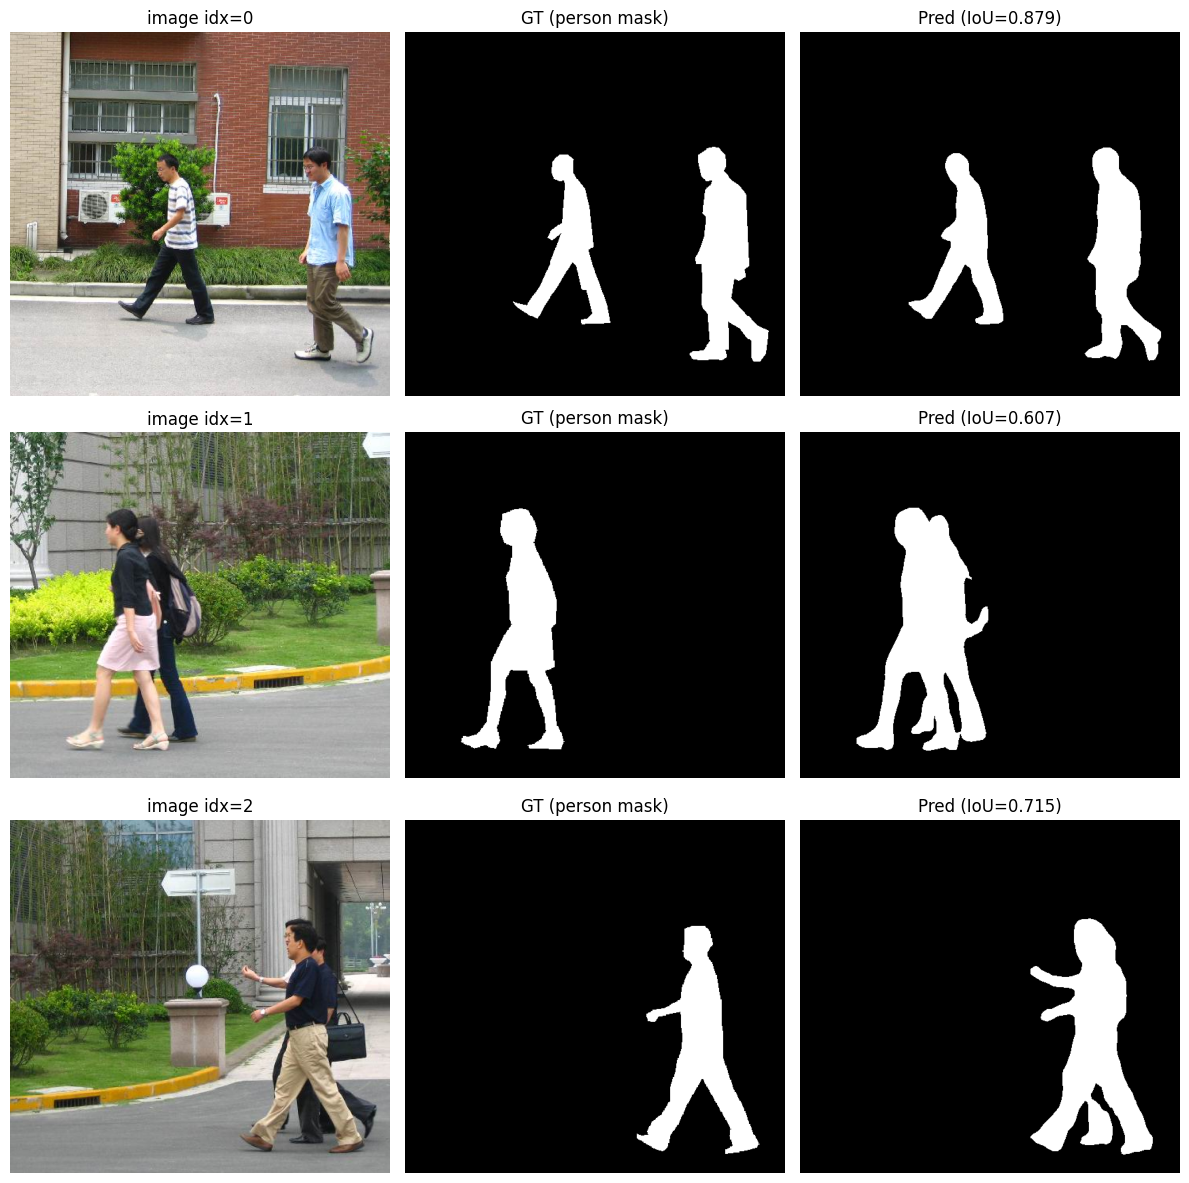

In [7]:
# 7) Визуализация: image / GT / pred
from torchvision.transforms import functional as F
from torchvision.transforms import InterpolationMode

n = min(cfg.n_show, len(dataset))
fig, axes = plt.subplots(n, 3, figsize=(12, 4*n))

if n == 1:
    axes = np.expand_dims(axes, axis=0)

for row in range(n):
    img_pil, gt_np = dataset[row]
    pred_mask, (h, w) = predict_person_mask(img_pil)

    # GT resize to model space
    gt_pil = Image.fromarray((gt_np * 255).astype(np.uint8))
    gt_rs = F.resize(gt_pil, size=[h, w], interpolation=InterpolationMode.NEAREST)
    gt_mask = (torch.from_numpy(np.array(gt_rs)) > 0).to(torch.uint8)

    iou = iou_binary(pred_mask, gt_mask)

    axes[row, 0].imshow(img_pil)
    axes[row, 0].set_title(f"image idx={row}")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(gt_mask.numpy(), cmap="gray")
    axes[row, 1].set_title("GT (person mask)")
    axes[row, 1].axis("off")

    axes[row, 2].imshow(pred_mask.numpy(), cmap="gray")
    axes[row, 2].set_title(f"Pred (IoU={iou:.3f})")
    axes[row, 2].axis("off")

plt.tight_layout()
plt.show()

## Замечания по метрике

1) Для бинарной маски «person vs background» IoU считается просто. Для многоклассовой сегментации обычно считают **mean IoU** по классам (с аккуратной обработкой отсутствующих классов).  
2) PennFudan даёт instance masks, а мы сделали из них бинарную маску. Это сознательное упрощение: нам важен корректный расчёт IoU и пайплайн валидации.
